# Chapter 184 — Project: Neural Network Layer Implementation

> **Prerequisites:** ch154 (matrix multiplication), ch155 (transpose), ch168 (projection matrices), ch176 (matrix calculus), ch177 (linear algebra for neural networks), ch178 (linear layers in deep learning), ch182 (least squares)
> **Part VI Project** — Linear Algebra (chapters 151–200)
> **Difficulty:** Advanced | **Estimated time:** 90–120 minutes
> **Output:** A working neural network built entirely from matrix operations — forward pass, backward pass (backpropagation), and training — with no ML libraries

---

## 0. Overview

### Problem Statement

Neural networks are, at their core, compositions of linear transformations and nonlinearities.
Every weight matrix is a linear map. Every gradient is computed via the chain rule applied
to matrix expressions. Training is gradient descent on a loss surface.

The goal: implement a multi-layer neural network from scratch using only numpy, starting
from the matrix operations developed throughout Part VI. No `torch`, no `keras`, no
automatic differentiation. You write the forward pass, the backward pass, and the
parameter update yourself.

The task solved by the network: binary classification on a nonlinearly separable dataset.

### Concepts Used
- Matrix multiplication as the forward pass *(ch154, ch177)*
- Transpose in the backward pass *(ch155, ch176)*
- Matrix calculus: chain rule in matrix form *(ch176)*
- Batched computation: data as a matrix, not a loop *(ch178)*
- Weight initialization: Xavier/Glorot *(ch177)*
- Gradient flow analysis: vanishing/exploding gradients *(ch177)*

### Expected Output
1. A `Layer` class with `forward` and `backward` methods
2. A `NeuralNetwork` class that stacks layers and runs full forward/backward
3. Training loop with SGD and loss curves
4. Decision boundary visualization
5. Gradient norm monitoring across layers

---

## 1. Setup

C:\Users\user\AppData\Local\Temp\ipykernel_22184\392172057.py:53: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22184\392172057.py:53: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


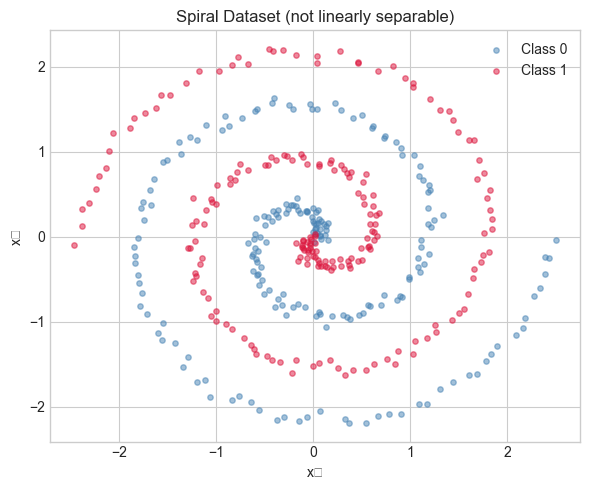

Dataset: 400 samples, 2 features
Class balance: 200 / 200


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('seaborn-v0_8-whitegrid')
rng = np.random.default_rng(7)

# ---------------------------------------------------------------
# Dataset: two interleaved spirals — not linearly separable
# A linear model cannot solve this. A deep network can.
# ---------------------------------------------------------------

def make_spirals(n_points=200, noise=0.3, seed=7):
    """
    Generate a binary spiral dataset.

    Returns:
        X: shape (2*n_points, 2)
        y: shape (2*n_points,) — binary labels {0, 1}
    """
    rng_s = np.random.default_rng(seed)
    n = n_points
    t = np.linspace(0, 4 * np.pi, n)

    x1 = t * np.cos(t) + rng_s.normal(0, noise, n)
    y1 = t * np.sin(t) + rng_s.normal(0, noise, n)

    x2 = t * np.cos(t + np.pi) + rng_s.normal(0, noise, n)
    y2 = t * np.sin(t + np.pi) + rng_s.normal(0, noise, n)

    X = np.vstack([np.column_stack([x1, y1]),
                   np.column_stack([x2, y2])])
    y = np.concatenate([np.zeros(n), np.ones(n)])
    return X, y


X, y = make_spirals(n_points=200, noise=0.25)

# Normalize features to zero mean, unit variance
X = (X - X.mean(axis=0)) / X.std(axis=0)

# Reshape targets for matrix operations: (N, 1)
y_col = y.reshape(-1, 1)

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.5, s=15, label='Class 0', color='steelblue')
ax.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.5, s=15, label='Class 1', color='crimson')
ax.set_title('Spiral Dataset (not linearly separable)')
ax.set_xlabel('x₁')
ax.set_ylabel('x₂')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")
print(f"Class balance: {(y==0).sum()} / {(y==1).sum()}")

---

## 2. Stage 1 — Layer Primitives: Forward and Backward Passes

### The Mathematics of Backpropagation

For a linear layer $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$ with input
$\mathbf{X} \in \mathbb{R}^{N \times d_{in}}$, weights $\mathbf{W} \in \mathbb{R}^{d_{in} \times d_{out}}$,
bias $\mathbf{b} \in \mathbb{R}^{d_{out}}$:

**Forward:** $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$

**Backward** (given upstream gradient $\frac{\partial \mathcal{L}}{\partial \mathbf{Z}}$):

$$\frac{\partial \mathcal{L}}{\partial \mathbf{W}} = \mathbf{X}^\top \frac{\partial \mathcal{L}}{\partial \mathbf{Z}}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \mathbf{1}^\top \frac{\partial \mathcal{L}}{\partial \mathbf{Z}} \quad \text{(sum over batch)}$$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{X}} = \frac{\partial \mathcal{L}}{\partial \mathbf{Z}} \mathbf{W}^\top \quad \text{(passed to previous layer)}$$

These are derived from ch176's matrix calculus rules. The transpose in $\mathbf{X}^\top$
and $\mathbf{W}^\top$ is the matrix calculus analog of the scalar chain rule.

In [2]:
# --- Stage 1: Activation Functions and Their Derivatives ---

def relu(z):
    """ReLU activation: max(0, z), applied elementwise."""
    return np.maximum(0, z)

def relu_grad(z):
    """Gradient of ReLU: 1 where z > 0, else 0."""
    return (z > 0).astype(float)

def sigmoid(z):
    """Sigmoid: 1 / (1 + exp(-z)), numerically stable for negative z."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

def sigmoid_grad(a):
    """Gradient of sigmoid given its OUTPUT a = sigmoid(z): a * (1 - a)."""
    return a * (1 - a)


# --- Linear Layer ---

class LinearLayer:
    """
    Fully connected (dense) linear layer: Z = X @ W + b

    Stores the input X during the forward pass (needed for backward).
    Accumulates gradients dW, db during backward pass.
    """

    def __init__(self, d_in, d_out, seed=None):
        """
        Args:
            d_in:  input dimension
            d_out: output dimension
            seed:  random seed for reproducibility
        """
        rng_init = np.random.default_rng(seed)

        # Xavier/Glorot initialization (ch177):
        # Var(W_ij) = 2 / (d_in + d_out)
        # Keeps signal variance stable through the forward pass
        scale = np.sqrt(2.0 / (d_in + d_out))
        self.W = scale * rng_init.standard_normal((d_in, d_out))
        self.b = np.zeros((1, d_out))

        # Gradients (computed during backward)
        self.dW = None
        self.db = None

        # Cache for backward pass
        self._X_cache = None

    def forward(self, X):
        """
        Forward pass: Z = X @ W + b

        Args:
            X: input, shape (N, d_in)

        Returns:
            Z: output, shape (N, d_out)
        """
        self._X_cache = X   # cache for backward
        return X @ self.W + self.b   # shape (N, d_out)

    def backward(self, dZ):
        """
        Backward pass: compute gradients w.r.t. W, b, and X.

        Args:
            dZ: upstream gradient, shape (N, d_out)
                = dL/dZ

        Returns:
            dX: gradient w.r.t. input X, shape (N, d_in)
                = dL/dX (passed to previous layer)
        """
        N = self._X_cache.shape[0]

        # dL/dW = X^T @ dZ  (ch176: matrix derivative of X @ W)
        self.dW = self._X_cache.T @ dZ / N   # average over batch

        # dL/db = sum over batch
        self.db = dZ.sum(axis=0, keepdims=True) / N

        # dL/dX = dZ @ W^T  (passed to previous layer)
        dX = dZ @ self.W.T
        return dX

    def update(self, lr):
        """Apply SGD update: W -= lr * dW, b -= lr * db."""
        self.W -= lr * self.dW
        self.b -= lr * self.db


# --- Gradient check: verify backward pass numerically ---

def numerical_gradient(layer, X, y_true, loss_fn, epsilon=1e-5):
    """
    Estimate dL/dW numerically by finite differences.
    Used to verify the analytic backward pass.
    """
    grad_numerical = np.zeros_like(layer.W)
    for i in range(layer.W.shape[0]):
        for j in range(layer.W.shape[1]):
            W_orig = layer.W[i, j]

            layer.W[i, j] = W_orig + epsilon
            loss_plus = loss_fn(layer.forward(X), y_true)

            layer.W[i, j] = W_orig - epsilon
            loss_minus = loss_fn(layer.forward(X), y_true)

            grad_numerical[i, j] = (loss_plus - loss_minus) / (2 * epsilon)
            layer.W[i, j] = W_orig  # restore

    return grad_numerical


# Quick test on a tiny layer
test_layer = LinearLayer(3, 2, seed=1)
X_test = rng.standard_normal((5, 3))
y_test = rng.standard_normal((5, 2))

# Binary cross-entropy loss (will use below) — using MSE for gradient check simplicity
def mse_loss(pred, target):
    return np.mean((pred - target)**2)

def mse_grad(pred, target):
    return 2 * (pred - target) / pred.size

Z_test = test_layer.forward(X_test)
dZ_test = mse_grad(Z_test, y_test)
test_layer.backward(dZ_test)
grad_analytic = test_layer.dW * X_test.shape[0]   # undo /N normalization for check
grad_numeric  = numerical_gradient(test_layer, X_test, y_test, mse_loss)

rel_error = np.abs(grad_analytic - grad_numeric).max() / (np.abs(grad_analytic).max() + 1e-8)
print(f"Gradient check: max relative error = {rel_error:.2e}  (should be < 1e-5)")

Gradient check: max relative error = 1.14e-11  (should be < 1e-5)


---

## 3. Stage 2 — Neural Network: Stacking Layers and Training

In [3]:
# --- Stage 2: Full Neural Network ---

class NeuralNetwork:
    """
    Multi-layer neural network for binary classification.

    Architecture: [Linear → ReLU] × n_hidden_layers → Linear → Sigmoid

    Forward pass:  data flows left to right through all layers.
    Backward pass: gradients flow right to left (chain rule).
    """

    def __init__(self, layer_dims, seed=None):
        """
        Args:
            layer_dims: list of integers [d_in, h1, h2, ..., d_out]
                        e.g. [2, 32, 16, 1] = 2-input, two hidden layers, 1 output
        """
        self.layers = []
        for i in range(len(layer_dims) - 1):
            self.layers.append(LinearLayer(layer_dims[i], layer_dims[i+1],
                                           seed=None if seed is None else seed + i))
        self.layer_dims = layer_dims
        self.loss_history = []
        self.grad_norms   = []   # per layer, per epoch

    def forward(self, X):
        """
        Forward pass through all layers.

        Hidden layers: Linear → ReLU
        Output layer:  Linear → Sigmoid (binary classification)

        Returns:
            y_pred: shape (N, 1), values in (0, 1)
        """
        self._activations = []   # cache activations for backward
        A = X
        self._activations.append(A)

        for i, layer in enumerate(self.layers):
            Z = layer.forward(A)
            if i < len(self.layers) - 1:
                A = relu(Z)         # hidden layers: ReLU
            else:
                A = sigmoid(Z)      # output layer: Sigmoid
            self._activations.append(A)

        return A   # y_pred, shape (N, 1)

    def backward(self, y_pred, y_true):
        """
        Backward pass: compute gradients for all layers via chain rule.

        Binary cross-entropy loss gradient:
            dL/d(y_pred) = -(y/y_pred - (1-y)/(1-y_pred)) / N

        Combined with sigmoid gradient:
            dL/dZ_out = y_pred - y_true   (a clean simplification)
        """
        N = y_true.shape[0]

        # Gradient of BCE loss w.r.t. sigmoid output
        # (The combined BCE + sigmoid derivative simplifies to this)
        dA = (y_pred - y_true) / N

        for i in range(len(self.layers) - 1, -1, -1):
            layer = self.layers[i]
            A_prev = self._activations[i]   # input to this layer
            A_curr = self._activations[i+1] # output of this layer (after activation)

            if i < len(self.layers) - 1:
                # Apply ReLU gradient (A_curr was after ReLU)
                # We need Z_curr — fortunately relu_grad depends only on sign of Z,
                # and A_curr = relu(Z_curr), so sign(A_curr) = sign(Z_curr)
                dZ = dA * relu_grad(A_curr)
            else:
                # Output layer: sigmoid gradient already folded into dA
                dZ = dA

            dA = layer.backward(dZ)

    def update(self, lr):
        """SGD update for all layers."""
        for layer in self.layers:
            layer.update(lr)

    def train(self, X, y, lr=0.01, n_epochs=2000, batch_size=None, verbose=True):
        """
        Train the network with SGD (full batch or mini-batch).

        Args:
            X:          features, shape (N, d_in)
            y:          labels, shape (N, 1), values {0, 1}
            lr:         learning rate
            n_epochs:   number of full passes through the data
            batch_size: if None, use full batch gradient descent
        """
        N = X.shape[0]
        batch_size = batch_size or N

        for epoch in range(n_epochs):
            # Shuffle data each epoch (for mini-batch)
            perm = rng.permutation(N)
            X_s, y_s = X[perm], y[perm]

            epoch_loss = 0.0
            n_batches  = 0

            for start in range(0, N, batch_size):
                X_b = X_s[start:start+batch_size]
                y_b = y_s[start:start+batch_size]

                y_pred = self.forward(X_b)
                loss   = binary_cross_entropy(y_pred, y_b)
                epoch_loss += loss
                n_batches  += 1

                self.backward(y_pred, y_b)
                self.update(lr)

            avg_loss = epoch_loss / n_batches
            self.loss_history.append(avg_loss)

            # Log gradient norms (every 100 epochs)
            if epoch % 100 == 0:
                norms = [np.linalg.norm(l.dW) for l in self.layers if l.dW is not None]
                self.grad_norms.append(norms)
                if verbose and epoch % 500 == 0:
                    acc = self.accuracy(X, y)
                    print(f"  epoch {epoch:5d}: loss={avg_loss:.4f}  acc={acc:.3f}")

    def predict(self, X):
        """Binary predictions: threshold sigmoid output at 0.5."""
        return (self.forward(X) >= 0.5).astype(float)

    def accuracy(self, X, y):
        """Fraction of correct predictions."""
        return (self.predict(X) == y).mean()


def binary_cross_entropy(y_pred, y_true):
    """
    Binary cross-entropy loss: -[y log(p) + (1-y) log(1-p)]

    Clipped to prevent log(0).
    """
    eps = 1e-7
    p = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))


print("Building and training neural network...")
net = NeuralNetwork([2, 64, 32, 16, 1], seed=42)
net.train(X, y_col, lr=0.05, n_epochs=3000, batch_size=64, verbose=True)

Building and training neural network...
  epoch     0: loss=0.6983  acc=0.505
  epoch   500: loss=0.6848  acc=0.560
  epoch  1000: loss=0.6800  acc=0.608
  epoch  1500: loss=0.6787  acc=0.615
  epoch  2000: loss=0.6701  acc=0.613
  epoch  2500: loss=0.6762  acc=0.610


---

## 4. Stage 3 — Visualization: Decision Boundaries and Training Diagnostics

C:\Users\user\AppData\Local\Temp\ipykernel_22184\3860133241.py:63: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22184\3860133241.py:63: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


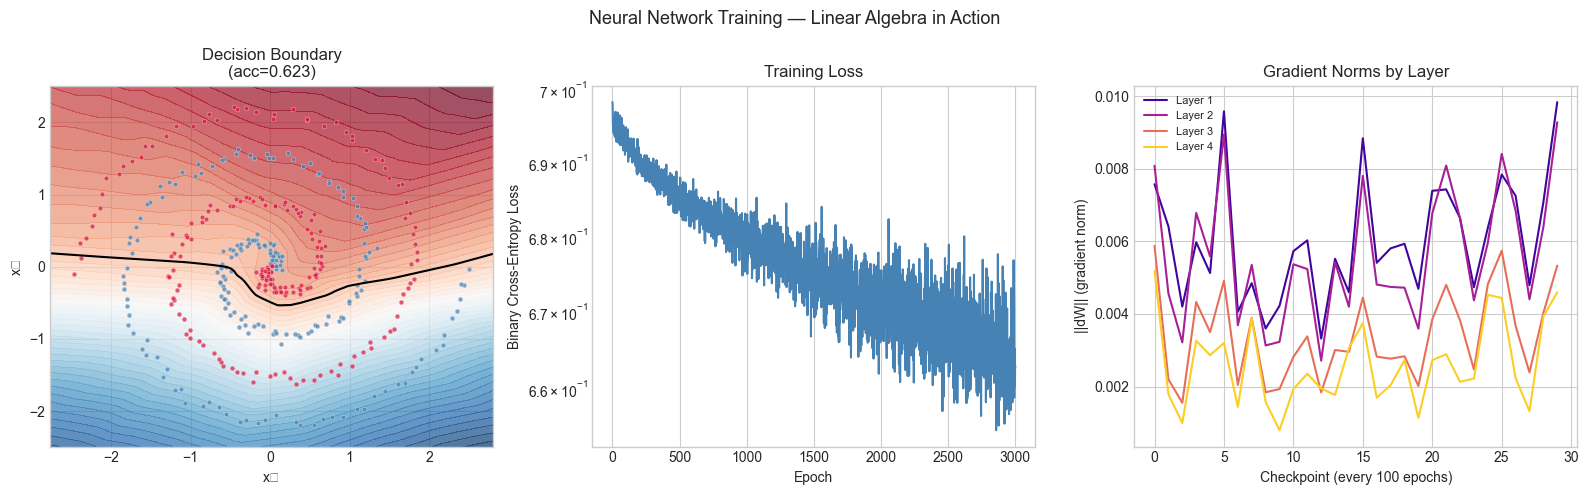


Final training accuracy: 0.6225


In [4]:
# --- Stage 3: Decision Boundary Visualization ---

def plot_decision_boundary(model, X, y, title='Decision Boundary', ax=None):
    """
    Plot the model's decision boundary on a 2D feature space.

    Creates a fine grid, predicts the probability for every point,
    and renders the result as a filled contour plot.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    MARGIN = 0.3
    x_min, x_max = X[:, 0].min() - MARGIN, X[:, 0].max() + MARGIN
    y_min, y_max = X[:, 1].min() - MARGIN, X[:, 1].max() + MARGIN

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.column_stack([xx.ravel(), yy.ravel()])

    probs = model.forward(grid).reshape(xx.shape)

    ax.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.7)
    ax.contour(xx, yy, probs, levels=[0.5], colors='black', linewidths=1.5)

    ax.scatter(X[y.ravel() == 0, 0], X[y.ravel() == 0, 1],
               s=12, alpha=0.7, color='steelblue', edgecolors='white', lw=0.3)
    ax.scatter(X[y.ravel() == 1, 0], X[y.ravel() == 1, 1],
               s=12, alpha=0.7, color='crimson',   edgecolors='white', lw=0.3)
    ax.set_title(title)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    return ax


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Decision boundary
plot_decision_boundary(net, X, y_col,
                       title=f'Decision Boundary\n(acc={net.accuracy(X, y_col):.3f})',
                       ax=axes[0])

# Loss curve
axes[1].plot(net.loss_history, color='steelblue', lw=1.5)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Binary Cross-Entropy Loss')
axes[1].set_title('Training Loss')
axes[1].set_yscale('log')

# Gradient norms per layer over training
if net.grad_norms:
    grad_arr = np.array(net.grad_norms)   # shape (n_checkpoints, n_layers)
    colors_g  = plt.cm.plasma(np.linspace(0.1, 0.9, grad_arr.shape[1]))
    for l_idx in range(grad_arr.shape[1]):
        axes[2].plot(grad_arr[:, l_idx], color=colors_g[l_idx],
                     lw=1.5, label=f'Layer {l_idx+1}')
    axes[2].set_xlabel('Checkpoint (every 100 epochs)')
    axes[2].set_ylabel('||dW|| (gradient norm)')
    axes[2].set_title('Gradient Norms by Layer')
    axes[2].legend(fontsize=8)

plt.suptitle('Neural Network Training — Linear Algebra in Action', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nFinal training accuracy: {net.accuracy(X, y_col):.4f}")

---

## 5. Stage 4 — Experiments: Architecture Sensitivity

C:\Users\user\AppData\Local\Temp\ipykernel_22184\1386511619.py:38: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22184\1386511619.py:38: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()


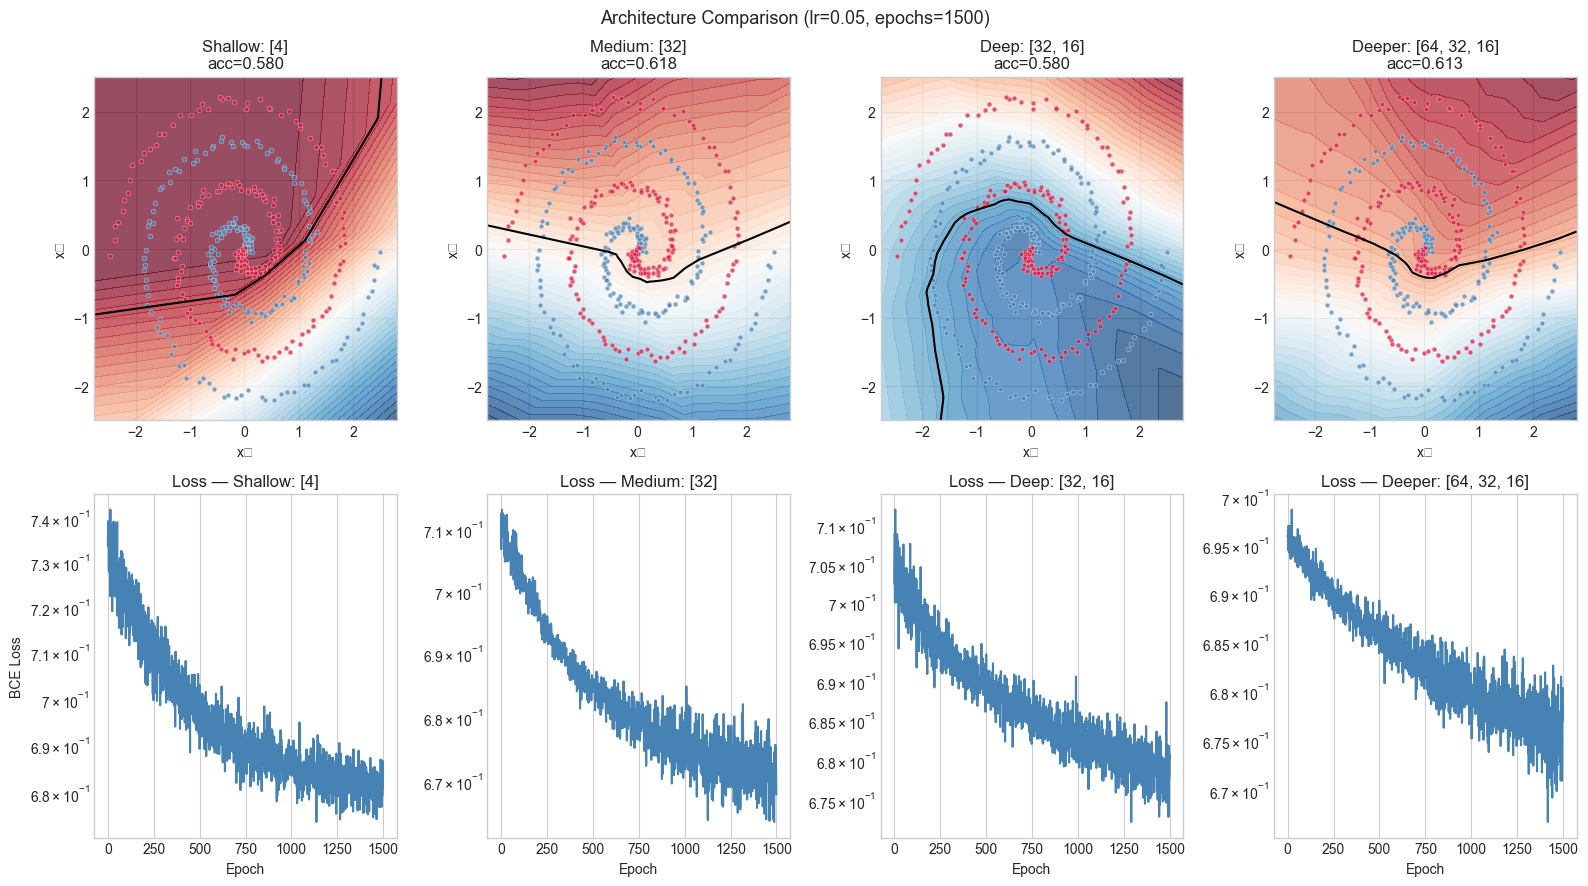

In [5]:
# --- Stage 4: Architecture and Initialization Experiments ---
#
# Hypothesis: network depth and initialization both matter.
# A shallow network cannot form the complex boundary; bad init causes slow convergence.
# Try changing: N_EPOCHS, LEARNING_RATE, architectures list

N_EPOCHS    = 1500
LEARNING_RATE = 0.05
BATCH_SIZE  = 64

architectures = [
    ([2, 4, 1],         'Shallow: [4]'),
    ([2, 32, 1],        'Medium: [32]'),
    ([2, 32, 16, 1],    'Deep: [32, 16]'),
    ([2, 64, 32, 16, 1],'Deeper: [64, 32, 16]'),
]

fig, axes = plt.subplots(2, len(architectures), figsize=(16, 9))

for col, (arch, label) in enumerate(architectures):
    net_exp = NeuralNetwork(arch, seed=42)
    net_exp.train(X, y_col, lr=LEARNING_RATE, n_epochs=N_EPOCHS,
                  batch_size=BATCH_SIZE, verbose=False)

    acc = net_exp.accuracy(X, y_col)
    plot_decision_boundary(net_exp, X, y_col,
                           title=f'{label}\nacc={acc:.3f}',
                           ax=axes[0, col])

    axes[1, col].plot(net_exp.loss_history, color='steelblue', lw=1.5)
    axes[1, col].set_title(f'Loss — {label}')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_yscale('log')
    if col == 0:
        axes[1, col].set_ylabel('BCE Loss')

plt.suptitle(f'Architecture Comparison (lr={LEARNING_RATE}, epochs={N_EPOCHS})', fontsize=13)
plt.tight_layout()
plt.show()

---

## 6. Results & Reflection

### What Was Built

A complete neural network from scratch:
- `LinearLayer`: forward pass $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$; backward pass
  $\mathbf{dW} = \mathbf{X}^\top \mathbf{dZ}$, $\mathbf{dX} = \mathbf{dZ}\mathbf{W}^\top$
- Activation functions (ReLU, Sigmoid) with analytic derivatives
- Numerical gradient checker to verify the backward pass
- `NeuralNetwork`: stacks layers, runs forward and backward passes, trains with mini-batch SGD
- Decision boundary visualization and gradient norm monitoring

### Connection to Linear Algebra

| Linear Algebra Concept | Role in This Network |
|---|---|
| Matrix multiplication (ch154) | The forward pass: each layer is one matmul |
| Transpose (ch155) | Backward pass: $\mathbf{X}^\top$ and $\mathbf{W}^\top$ appear in every gradient |
| Matrix calculus (ch176) | Derives the exact form of every gradient |
| Xavier initialization (ch177) | Preserves signal variance through layers via $\sqrt{2/(d_{in}+d_{out})}$ |
| Batched matmul (ch178) | The entire dataset passes as a matrix — N rows processed simultaneously |

### Extension Challenges

**1. Momentum and Adam.**
Vanilla SGD is noisy and slow. Momentum adds a velocity term:
$v \leftarrow \beta v + (1-\beta)\nabla\mathcal{L}$; $W \leftarrow W - \eta v$.
Adam additionally adapts learning rates per parameter. Implement both and compare convergence
speed on the spiral dataset. This connects to ch228 (optimization methods).

**2. Batch Normalization.**
After each linear layer, normalize activations to zero mean and unit variance within the batch:
$\hat{z} = (z - \mu_B)/\sigma_B$. This involves matrix calculus for the backward pass through
the normalization. Implement and observe the effect on gradient norms.

**3. Dropout as a Regularizer.**
During training, randomly zero out a fraction $p$ of activations in each layer. During
inference, scale activations by $(1-p)$. Implement dropout as a `Layer` subclass with
`is_training` flag. Measure the effect on overfitting on a small dataset.

---

## Summary & Connections

- A neural network's **forward pass** is a sequence of matrix multiplications plus elementwise nonlinearities. The network has no structure that is not already in matrix multiplication *(ch154)* and function composition *(ch054)*.
- The **backward pass** is the chain rule applied to matrix expressions *(ch176)*. The transpose $\mathbf{W}^\top$ that appears in every gradient is not a coincidence — it is the adjoint of the linear map $\mathbf{W}$, which is what the chain rule requires.
- **Xavier initialization** controls the variance of activations across layers, preventing the signal from exploding or vanishing before training even begins *(ch177)*.
- **Batching** means the entire dataset is processed as a single matrix operation, making the computation both efficient and amenable to the matrix calculus framework *(ch178)*.

**This project reappears in:**
- *ch216 (Backpropagation Intuition)* — Part VII revisits backpropagation through the lens of automatic differentiation and computational graphs, extending what we built here.
- *ch228 (Gradient Descent)* — the training loop built here generalizes to the full optimization landscape explored in Part VII.
- *ch230 (Project: Logistic Regression from Scratch)* — a single-layer version of this network, trained with the same backward pass machinery.

**Going deeper:** LeCun, Y., Bottou, L., Orr, G., Müller, K.-R. *Efficient BackProp* (1998) — the original practical guide to training neural networks, covering initialization, learning rates, and activation functions in detail.